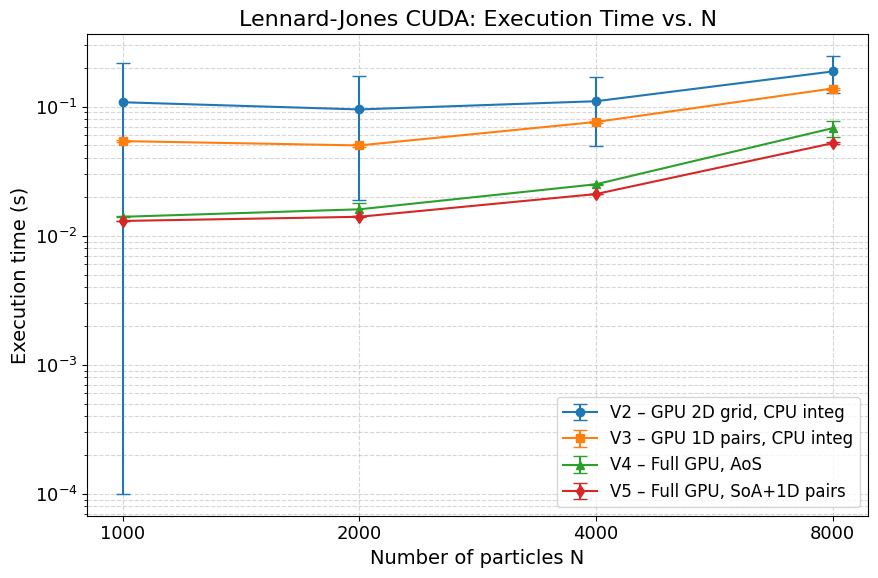

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12
})

# Benchmark data (avg +/- std, 5 runs, 100 steps, includes GPU transfers)
N = np.array([1000, 2000, 4000, 8000])

T_v2_avg = np.array([0.108, 0.095, 0.110, 0.187])
T_v2_std = np.array([0.1079, 0.0760, 0.0604, 0.0585])

T_v3_avg = np.array([0.054, 0.050, 0.076, 0.138])
T_v3_std = np.array([0.0008, 0.0011, 0.0014, 0.0025])

T_v4_avg = np.array([0.014, 0.016, 0.025, 0.068])
T_v4_std = np.array([0.0001, 0.0019, 0.0001, 0.0099])

T_v5_avg = np.array([0.013, 0.014, 0.021, 0.052])
T_v5_std = np.array([0.0001, 0.0001, 0.0000, 0.0009])

# Plot 1: Execution time vs. N with error bars
fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(N, T_v2_avg, yerr=T_v2_std, fmt='-o', capsize=5, label='V2 – GPU 2D grid, CPU integ')
ax.errorbar(N, T_v3_avg, yerr=T_v3_std, fmt='-s', capsize=5, label='V3 – GPU 1D pairs, CPU integ')
ax.errorbar(N, T_v4_avg, yerr=T_v4_std, fmt='-^', capsize=5, label='V4 – Full GPU, AoS')
ax.errorbar(N, T_v5_avg, yerr=T_v5_std, fmt='-d', capsize=5, label='V5 – Full GPU, SoA+1D pairs')

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(N)
ax.set_xticklabels([str(n) for n in N])
ax.set_xlabel('Number of particles N')
ax.set_ylabel('Execution time (s)')
ax.set_title('Lennard-Jones CUDA: Execution Time vs. N')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('execution_time_vs_N.png', dpi=300)
plt.show()

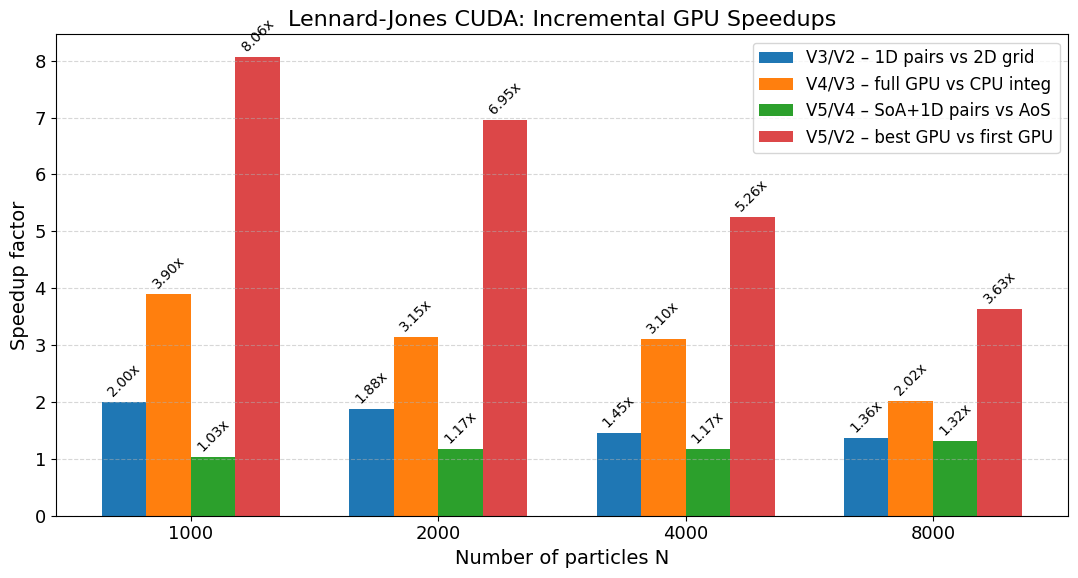

In [2]:
# Plot 2: Incremental GPU speedups (grouped bar chart)

S_v3_v2 = np.array([2.00, 1.88, 1.45, 1.36])
S_v4_v3 = np.array([3.90, 3.15, 3.10, 2.02])
S_v5_v4 = np.array([1.03, 1.17, 1.17, 1.32])
S_v5_v2 = np.array([8.06, 6.95, 5.26, 3.63])

x = np.arange(len(N))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - 1.5*width, S_v3_v2, width, label='V3/V2 – 1D pairs vs 2D grid')
bars2 = ax.bar(x - 0.5*width, S_v4_v3, width, label='V4/V3 – full GPU vs CPU integ')
bars3 = ax.bar(x + 0.5*width, S_v5_v4, width, label='V5/V4 – SoA+1D pairs vs AoS')
bars4 = ax.bar(x + 1.5*width, S_v5_v2, width, label='V5/V2 – best GPU vs first GPU', color='tab:red', alpha=0.85)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f}x',
                ha='center', va='bottom', fontsize=10, rotation=45)

ax.set_xlabel('Number of particles N')
ax.set_ylabel('Speedup factor')
ax.set_title('Lennard-Jones CUDA: Incremental GPU Speedups')
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in N])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('speedup_incremental.png', dpi=300)
plt.show()

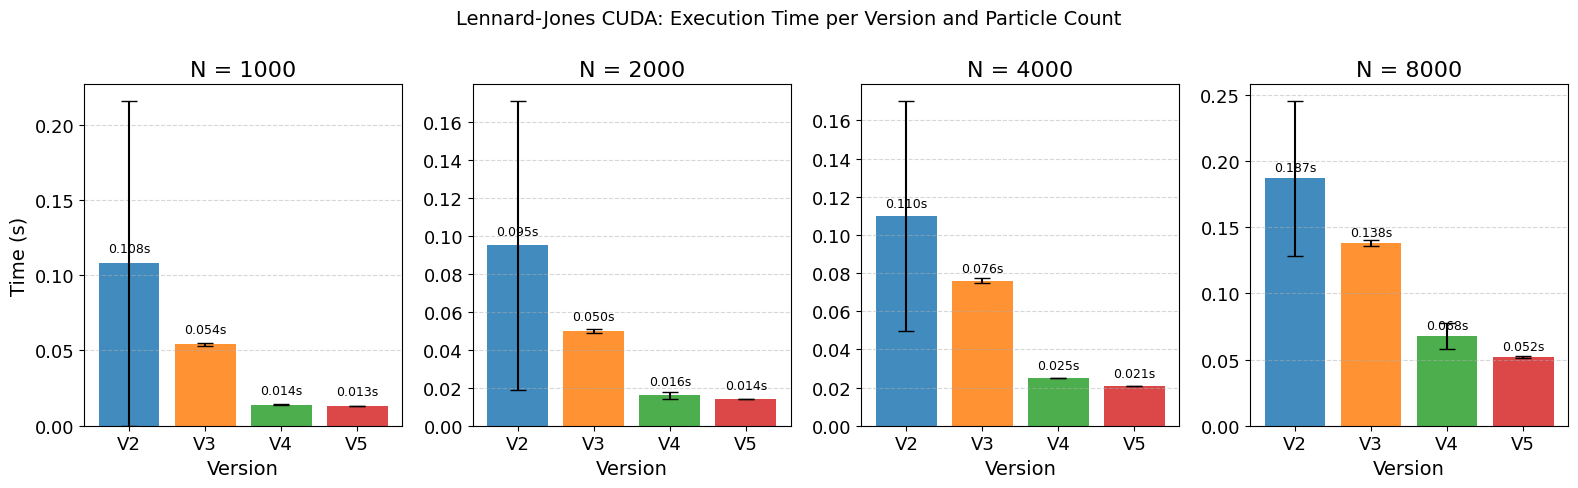

In [3]:
# Plot 3: All version times side-by-side for each N

versions = ['V2', 'V3', 'V4', 'V5']
times_by_N = {
    1000: [0.108, 0.054, 0.014, 0.013],
    2000: [0.095, 0.050, 0.016, 0.014],
    4000: [0.110, 0.076, 0.025, 0.021],
    8000: [0.187, 0.138, 0.068, 0.052],
}
stds_by_N = {
    1000: [0.1079, 0.0008, 0.0001, 0.0001],
    2000: [0.0760, 0.0011, 0.0019, 0.0001],
    4000: [0.0604, 0.0014, 0.0001, 0.0000],
    8000: [0.0585, 0.0025, 0.0099, 0.0009],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, n in zip(axes, N):
    avgs = times_by_N[n]
    stds = stds_by_N[n]
    bars = ax.bar(versions, avgs, yerr=stds, capsize=6, color=colors, alpha=0.85, ecolor='black')
    ax.set_title(f'N = {n}')
    ax.set_ylabel('Time (s)' if n == 1000 else '')
    ax.set_xlabel('Version')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, avg in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width()/2, avg + max(stds)*0.05,
                f'{avg:.3f}s', ha='center', va='bottom', fontsize=9)

fig.suptitle('Lennard-Jones CUDA: Execution Time per Version and Particle Count', fontsize=14)
plt.tight_layout()
plt.savefig('time_per_version_per_N.png', dpi=300)
plt.show()

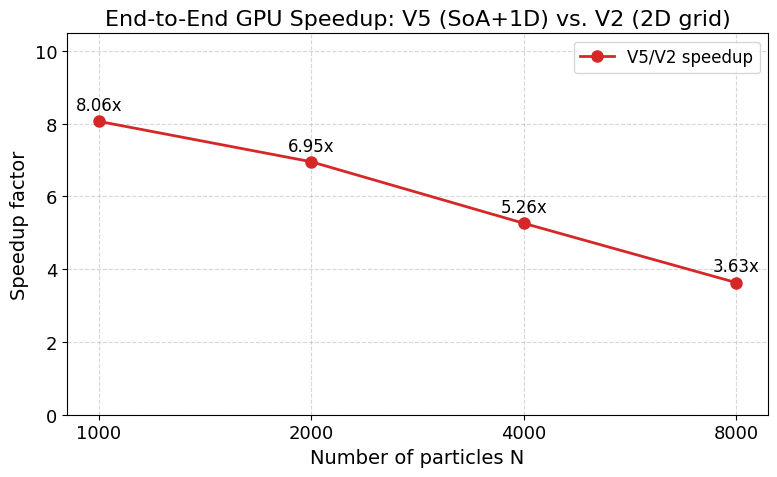

In [4]:
# Plot 4: End-to-end GPU speedup (V5 vs V2) as a function of N

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(N, S_v5_v2, marker='o', linewidth=2, markersize=8, color='tab:red', label='V5/V2 speedup')
for xi, yi in zip(N, S_v5_v2):
    ax.annotate(f'{yi:.2f}x', xy=(xi, yi), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=12)

ax.set_xscale('log', base=2)
ax.set_xticks(N)
ax.set_xticklabels([str(n) for n in N])
ax.set_xlabel('Number of particles N')
ax.set_ylabel('Speedup factor')
ax.set_title('End-to-End GPU Speedup: V5 (SoA+1D) vs. V2 (2D grid)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim(0, max(S_v5_v2) * 1.3)

plt.tight_layout()
plt.savefig('end_to_end_speedup.png', dpi=300)
plt.show()